In [1]:
#这两行代码是告诉ipynb，只要我运行cell，就去检查旁边.py文件看有没有被修改，如果修改了就重新读入

#读取之前用的函数
from functions import metrics_from_bt
#读取本地数据的代码
import pandas as pd
import numpy as np

# 1. 一步到位：读取 CSV，同时告诉 Pandas 把第 0 列当成索引，并尝试解析为时间格式
clean_data_path = "data/BTCUSDT_1h_6y_cleaned.csv"
df = pd.read_csv(clean_data_path, index_col=0, parse_dates=True)

# 2. (可选) 终极保险：强制确认一下索引是 UTC 时区格式
# 有时候 CSV 存取会丢失时区信息，加上这句可以保证万无一失
df.index = pd.to_datetime(df.index, utc=True)

# 检查结果
print("数据前 3 行：\n", df.head(3))
print("\n当前的索引类型：\n", type(df.index))

df6y=df

# 1) 全数据
df_full = df6y.copy()
df_full = df_full.sort_index()

# 2) 数据长度
n = len(df_full)

# 3) 切分位置
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# 4) 三段数据
train_df = df_full.iloc[:train_end].copy()
val_df   = df_full.iloc[train_end:val_end].copy()
test_df  = df_full.iloc[val_end:].copy()
print("Total rows :", len(df_full))
print("Train rows :", len(train_df))
print("Val rows   :", len(val_df))
print("Test rows  :", len(test_df))

数据前 3 行：
                               open     high      low    close       volume  \
2020-03-01 00:00:00+00:00  8523.61  8613.57  8511.11  8547.25  1952.740520   
2020-03-01 01:00:00+00:00  8546.65  8649.00  8514.06  8639.28  1901.273287   
2020-03-01 02:00:00+00:00  8640.23  8675.00  8617.73  8630.86  1271.182357   

                                                 close_time  \
2020-03-01 00:00:00+00:00  2020-03-01 00:59:59.999000+00:00   
2020-03-01 01:00:00+00:00  2020-03-01 01:59:59.999000+00:00   
2020-03-01 02:00:00+00:00  2020-03-01 02:59:59.999000+00:00   

                           quote_asset_volume  number_of_trades  \
2020-03-01 00:00:00+00:00        1.673789e+07           22876.0   
2020-03-01 01:00:00+00:00        1.630347e+07           24731.0   
2020-03-01 02:00:00+00:00        1.098729e+07           16257.0   

                           taker_buy_base_asset_volume  \
2020-03-01 00:00:00+00:00                   899.851144   
2020-03-01 01:00:00+00:00              

In [2]:
# ============================================================
# Core variables used in Phase 5
# ============================================================

# 使用 train 数据做研究
df = train_df.copy()


# ------------------------------------------------------------
# Returns
# ------------------------------------------------------------

ret = df["close"].pct_change()


# ------------------------------------------------------------
# Volatility estimator
# ------------------------------------------------------------

vol_window = 48

vol = ret.rolling(vol_window).std()


print("Return / Vol ready")

Return / Vol ready


# Phase 5 — Alpha Combination
## Task 5.1 — Build a complete multi-horizon backtest

### Objective

In Phase 4, we established a strong single-horizon baseline using:

- EMA trend
- volatility normalization
- dynamic threshold
- tanh mapping
- vol targeting
- transaction cost

Now we move to Phase 5.

The goal is to test whether combining multiple momentum horizons can improve the strategy.

### Key idea

Different EMA horizon pairs may capture different time scales of trend:

- shorter horizons react faster
- longer horizons may be more stable
- combining them may improve robustness

### Research principle

We will keep the full strategy pipeline unchanged:

EMA trend  
→ vol normalization  
→ dynamic threshold  
→ tanh direction  
→ alpha combination  
→ vol targeting  
→ transaction cost

This ensures that the only new research object in Phase 5 is:

**how to combine multiple horizon signals**

### Combination methods in the first version

We start with two simple methods:

1. equal-weight combination  
2. inverse-vol weighting

This is the cleanest way to begin Phase 5.

# 标准pipelin：raw trend → normalize → threshold/dynamic threshold → squash(tanh) → combine → vol target → cost


Phase 5 — Alpha Combination
Research Objective

在 Phase 4 之前，我们已经完成：

单信号 EMA Trend Alpha

signal normalization

dynamic threshold

tanh position squashing

volatility targeting

transaction cost

目前我们已经拥有一个完整可交易策略 pipeline。

Phase 5 的目标是研究：

多个 horizon 的 momentum 信号是否能通过合理组合，提升策略稳定性或风险收益比。

关键问题：

单 horizon 是否已经足够好？

多 horizon 是否提供 增量信息？

不同组合方式是否能改善：

Sharpe

Max Drawdown

Stability

Turnover

#### 所有候选策略必须走 完全相同的 pipeline

EMA Trend

      ↓

Vol Normalization

      ↓

Dynamic Threshold

      ↓

tanh(signal)

      ↓

Alpha Combination

      ↓

Vol Targeting

      ↓
Transaction Cost

      ↓

Backtest Evaluation


## Single Horizon Baseline

trend\
signal\
threshold\
tanh\
vol targeting\
backtest\
metrics

#### 例如（示意结构）

#### Task 5.1 — Build the first complete multi-horizon backtest function

在 Phase 4 里，你已经有了一个很强的单信号 baseline

现在进入 Phase 5，我们不再只研究一个 horizon，比如 (48, 336)，而是想问：

如果同时看多个 horizon 的 trend，它们能不能组合成一个更稳、更强、或者回撤更小的策略？

这就是 Alpha Combination。

### 为什么要做多 horizon？

因为不同 horizon 看的“趋势尺度”不一样。

举例：

(12, 72) 更偏短中期

(48, 336) 更偏中长期

(96, 336) 更偏慢趋势

它们有可能：

在不同市场阶段表现不同

对同一个趋势的反应速度不同

有些更敏感，有些更稳

所以组合多 horizon 的核心假设是：

**市场趋势不是只有一个时间尺度，多个时间尺度可能提供增量信息。**

但这只是“假设”，不是结论。
所以 Phase 5 的任务就是验证它。




### 那么我们下面要加入一个新回测函数，是多周期的合成：

这个函数要把下面整套流程一次性做完：

对每个 horizon：

1.计算 EMA trend

2.用市场波动率做标准化

3.做 dynamic threshold

4.做 tanh 映射，得到连续方向信号

然后：

5.把多个 horizon 信号组合起来

6.再做统一的 vol targeting

7.再算 cost / strategy return / equity / drawdown

这才是一个真正可比较的 multi-horizon 策略。


### 为什么组合要放在 vol targeting 前面？

这是一个很关键的设计选择。

我们现在研究的是：

多个 alpha sleeve 组合成一个策略

而不是：

9 个完整独立策略先各自做完风险控制，再把 9 个策略拼起来

所以更合理的顺序是：

多个 signal
→
先组合成一个方向信号
→
再统一做 vol targeting
多个 signal→先组合成一个方向信号→再统一做 vol targeting

这样逻辑更干净，因为：

horizon 之间的差别只体现在 alpha 层

风险控制层保持统一

比较结果更可解释

#### 先做哪两种组合方式？

我们先只做两种，保持主线清晰：

1. Equal Weight

所有 horizon 等权平均。

2. Inverse-Vol Weighting

你之前口头说 risk parity，但在我们现在这个阶段，更准确地说是：

inverse-vol alpha weighting

也就是：

波动更大的 signal，权重更小

波动更小的 signal，权重更大

公式= $$ w_i \propto \frac{1}{\sigma_i} $$

然后再归一化，这个版本不是严格的ERC/risk partiy，只是一个非常使用的第一版“风险平衡”

## 第一代码cell：定义horizon组合

In [ ]:
# ============================================================
# Phase 5 — Task 5.1
# Step 1 — Define multi-horizon EMA pairs
# ============================================================

horizon_pairs = [  #定义新列表为每一部分的信号
    (12, 72),
    (12, 168),
    (12, 336),
    (24, 72),
    (24, 168),
    (24, 336),
    (48, 168),
    (48, 336),
    (96, 336),
]

print("Number of horizon pairs:", len(horizon_pairs))
print("Pairs:")
for pair in horizon_pairs:
    print(pair)

Number of horizon pairs: 9
Pairs:
(12, 72)
(12, 168)
(12, 336)
(24, 72)
(24, 168)
(24, 336)
(48, 168)
(48, 336)
(96, 336)


为什么这样做？

因为后面 multi-horizon 函数会循环遍历这个列表，对每个 pair：

算 trend

算 signal

做 threshold

做 tanh

最后再组合。

也就是说，这个列表定义的是：

多信号策略由哪些 alpha sleeve 组成

## 第二代码cell 多期合成信号+动态阈值+vol控制的完整回测



In [5]:
# ============================================================
# Phase 5 — Task 5.1
# Step 2 — First version of multi-horizon backtest function
# ============================================================

def backtest_multi_horizon_dynamic_threshold(
    df,
    horizon_pairs,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold_window=24 * 7,
    threshold_quantile=0.7,
    combine_method="equal",   # "equal" or "inverse_vol"
    fee_rate=0.0004,
    max_leverage=3.0,
    weight_vol_window=24 * 7,
):
    """
    Multi-horizon trend strategy with:
    - EMA trend signal
    - volatility normalization
    - dynamic threshold
    - tanh signal mapping
    - alpha combination
    - portfolio-level vol targeting
    - transaction cost

    Parameters
    ----------
    df : pd.DataFrame
        Must contain at least column 'close'
    horizon_pairs : list of tuples
        Example: [(12,72), (24,168), (48,336)]
    vol_lookback : int
        Rolling window for realized market volatility
    target_vol_annual : float
        Annualized target volatility
    threshold_window : int
        Rolling window for dynamic threshold
    threshold_quantile : float
        Quantile level for dynamic threshold
    combine_method : str
        "equal" or "inverse_vol"
    fee_rate : float
        Cost per 1x turnover
    max_leverage : float
        Max cap for vol-targeted size
    weight_vol_window : int
        Rolling window used in inverse-vol weighting

    Returns
    -------
    bt : pd.DataFrame
        Standard backtest output
    """

    data = df.copy().sort_index()

    # --------------------------------------------------------
    # 1) Market return
    # --------------------------------------------------------
    ret = data["close"].pct_change()

    # --------------------------------------------------------
    # 2) Shared market volatility estimate
    # --------------------------------------------------------
    realized_vol = ret.rolling(vol_lookback).std().replace(0, np.nan)


# 这一步realized_vol是共享市场波动率，对“回报率”过去三天取其标准差
#可以对每个时段的 trend signal 做标准化，即trend/relized_vol
# 给最终组合策略做vol targeting size这个变量也是用这个vol，是目标σ/市场σ




    # --------------------------------------------------------
    # 3) Build one filtered direction signal per horizon
    # --------------------------------------------------------
    direction_dict = {}
    filtered_signal_dict = {}


#每个horizon先单独生成方向信号
#这样每个horizon最后都变成一列：direction_i，取值在[-1，1]
#为什么不是直接组合 trend？
#因为你当前主线策略不是“原始 trend 策略”，而是： 经过完整筛选和变换后的 signal 策略
#所以 Phase 5 要尊重你 Phase 4 已经建立好的 pipeline。
#不能突然退回到更原始的 trend 层去比，否则会失去一致性。

    for ema_fast, ema_slow in horizon_pairs:
        col_name = f"{ema_fast}_{ema_slow}"

        # EMA trend
        ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
        ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()
        trend = ema_fast_series / ema_slow_series - 1.0

        # Risk-adjusted signal
        signal = trend / realized_vol

        # Dynamic threshold
        signal_strength = signal.abs()
        dynamic_threshold = signal_strength.rolling(threshold_window).quantile(threshold_quantile)

        filtered_signal = signal.copy()
        filtered_signal[signal_strength < dynamic_threshold] = 0.0

        # Continuous direction in [-1, 1]
        direction = np.tanh(filtered_signal).fillna(0.0)

        direction_dict[col_name] = direction
        filtered_signal_dict[col_name] = filtered_signal

    directions_df = pd.DataFrame(direction_dict, index=data.index)
    filtered_signals_df = pd.DataFrame(filtered_signal_dict, index=data.index)




    
    
    # 组合方法分为equal和inverse_vol
    # --------------------------------------------------------
    # 4) Combine multiple horizon directions
    # --------------------------------------------------------
    if combine_method == "equal":
        combined_direction = directions_df.mean(axis=1)
#equal法是每个horizon权重一样，算是baseline combination

    elif combine_method == "inverse_vol":
        signal_vol = directions_df.rolling(weight_vol_window).std().replace(0, np.nan)
        inv_vol = 1.0 / signal_vol
        weights = inv_vol.div(inv_vol.sum(axis=1), axis=0).fillna(0.0)
        combined_direction = (directions_df * weights).sum(axis=1)

# inverse_vol法的计算逻辑，先算每个信号最近一段时间的波动，
#然后设权重为 inv_vol 即波动更大权重小，波动小权重大
#为什么这么做？
#因为有些horizon波动很大，容易在组合里过度主导，这算是平衡风险
    else:
        raise ValueError("combine_method must be either 'equal' or 'inverse_vol'")



#然后统一做vol targeting
    # --------------------------------------------------------
    # 5) Portfolio-level vol targeting
    # --------------------------------------------------------
    target_vol_hourly = target_vol_annual / np.sqrt(24 * 365)
    size = (target_vol_hourly / realized_vol).clip(upper=max_leverage).fillna(0.0)

    target_pos = combined_direction * size

    # --------------------------------------------------------
    # 6) Avoid look-ahead
    # --------------------------------------------------------
    pos = target_pos.shift(1).fillna(0.0)

    # --------------------------------------------------------
    # 7) Turnover and cost
    # --------------------------------------------------------
    turnover = pos.diff().abs().fillna(0.0)
    cost = fee_rate * turnover

    # --------------------------------------------------------
    # 8) Strategy return
    # --------------------------------------------------------
    strategy_ret = pos * ret - cost

    # --------------------------------------------------------
    # 9) Equity curve and drawdown
    # --------------------------------------------------------
    equity = (1.0 + strategy_ret.fillna(0.0)).cumprod()
    peak = equity.cummax()
    drawdown = equity / peak - 1.0
#multi-horizon策略和single-horizon 策略保持在执行层完全一样
    # --------------------------------------------------------
    # 10) Pack output
    # --------------------------------------------------------
    bt = pd.DataFrame({
        "close": data["close"],
        "ret": ret,
        "realized_vol": realized_vol,
        "combined_direction": combined_direction,
        "size": size,
        "target_pos": target_pos,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown,
    }, index=data.index)

    return bt

## Cell3 跑一个equal法的回测，在训练集上

In [6]:
# ============================================================
# Phase 5 — Task 5.1
# Step 3 — First run on TRAIN: equal-weight multi-horizon
# ============================================================

bt_multi_equal_train = backtest_multi_horizon_dynamic_threshold(
    df=train_df,
    horizon_pairs=horizon_pairs,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold_window=24 * 7,
    threshold_quantile=0.7,
    combine_method="equal",
    fee_rate=0.0004,
    max_leverage=3.0,
    weight_vol_window=24 * 7,
)

metrics_multi_equal_train = metrics_from_bt(bt_multi_equal_train)
print("Multi-horizon Equal Weight (TRAIN):", metrics_multi_equal_train)

bt_multi_equal_train[["equity", "drawdown"]].tail()

Multi-horizon Equal Weight (TRAIN): (0.4117188016873038, -0.1768064319900633, 0.17312711657929203)


,equity,drawdown
2023-10-06 10:00:00+00:00,1.174522,-0.021236
2023-10-06 11:00:00+00:00,1.174815,-0.020992
2023-10-06 12:00:00+00:00,1.173163,-0.022368
2023-10-06 13:00:00+00:00,1.173127,-0.022398
2023-10-06 14:00:00+00:00,1.173127,-0.022398


## Cell4 再跑inverse-vol版本在train上

In [ ]:
# ============================================================
# Phase 5 — Task 5.1
# Step 4 — First run on TRAIN: inverse-vol multi-horizon
# ============================================================

bt_multi_invvol_train = backtest_multi_horizon_dynamic_threshold(
    df=train_df,
    horizon_pairs=horizon_pairs,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold_window=24 * 7,
    threshold_quantile=0.7,
    combine_method="inverse_vol",
    fee_rate=0.0004,
    max_leverage=3.0,
    weight_vol_window=24 * 7,
)

metrics_multi_invvol_train = metrics_from_bt(bt_multi_invvol_train)
print("Multi-horizon Inverse-Vol (TRAIN):", metrics_multi_invvol_train)

bt_multi_invvol_train[["equity", "drawdown"]].tail()

Multi-horizon Inverse-Vol (TRAIN): (0.23129769888950144, -0.18526336965885015, 0.07997312417427294)


,equity,drawdown
2023-10-06 10:00:00+00:00,1.081270,-0.097257
2023-10-06 11:00:00+00:00,1.081541,-0.097031
2023-10-06 12:00:00+00:00,1.080007,-0.098312
2023-10-06 13:00:00+00:00,1.079973,-0.098340
2023-10-06 14:00:00+00:00,1.079973,-0.098340


## Cell 5 和single-horizon baseline做第一次并排比较

In [8]:
from functions import backtest_single_horizon_dynamic_threshold
# ============================================================
# Phase 5 — Task 5.1
# Step 5 — Compare against single-horizon baseline on TRAIN
# ============================================================

bt_single_train = backtest_single_horizon_dynamic_threshold(
    df=train_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold_window=24 * 7,
    threshold_quantile=0.7,
    fee_rate=0.0004,
    max_leverage=3.0
)

comparison = pd.DataFrame({
    "single_48_336": metrics_from_bt(bt_single_train),
    "multi_equal": metrics_from_bt(bt_multi_equal_train),
    "multi_inverse_vol": metrics_from_bt(bt_multi_invvol_train),
}, index=["sharpe", "maxdd", "totalret"]).T

comparison

,sharpe,maxdd,totalret
single_48_336,0.360838,-0.240552,0.166258
multi_equal,0.411719,-0.176806,0.173127
multi_inverse_vol,0.231298,-0.185263,0.079973


## 结果解读

从结果看multi-horizon还算是有一些研究价值

## 为什么 inverse-vol这么差？

原因1：强 alpha 稀释了\
      如果：强 alpha 恰好比较 volatile 就会被压权重，组合变弱

原因2：这些horizon本身高度相关\
      如果corr都在0.7-0.9，说明他们都在捕捉一个趋势结构

原因3：direction 信号本身波动差异不大\
      因为inverse-vol用的是单direction的std，但是direction用的是tanh\
      tanh把范围压小了，所以本身vol差异不大

## 接下来不要去在train上调各种组合，去看validation

如果validation还能赢，说明多期组合真有价值，不然就是noise
      



## Cell6 validation对比

In [9]:
# ============================================================
# Phase 5 — Task 5.2
# Validation Comparison
# ============================================================

# ----- single horizon -----

bt_single_val = backtest_single_horizon_dynamic_threshold(
    df=val_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold_window=24 * 7,
    threshold_quantile=0.7,
    fee_rate=0.0004,
    max_leverage=3.0
)

# ----- multi equal -----

bt_multi_equal_val = backtest_multi_horizon_dynamic_threshold(
    df=val_df,
    horizon_pairs=horizon_pairs,
    combine_method="equal"
)

# ----- multi inverse vol -----

bt_multi_invvol_val = backtest_multi_horizon_dynamic_threshold(
    df=val_df,
    horizon_pairs=horizon_pairs,
    combine_method="inverse_vol"
)

# ----- comparison table -----

comparison_val = pd.DataFrame({
    "single_48_336": metrics_from_bt(bt_single_val),
    "multi_equal": metrics_from_bt(bt_multi_equal_val),
    "multi_inverse_vol": metrics_from_bt(bt_multi_invvol_val),
}, index=["sharpe", "maxdd", "totalret"]).T

comparison_val

,sharpe,maxdd,totalret
single_48_336,1.442064,-0.096372,0.266888
multi_equal,1.569745,-0.090583,0.246477
multi_inverse_vol,1.461317,-0.100437,0.228797


在这里之后下一步，很多人会疯狂调combine方法比如：

PCA weighting

IC weighting

covariance risk parity

optimize

但这不科学，我们已有simple+stable+validation还可以的组合了，下一步应该去看那些horizon真实有用的，9个还是太多，3-5个合适。

这样可以第一降低过拟合风险，第二提高策略可解释性，第三提高稳定性

## Cell7 先画个sigle correlation 的矩阵图看看

In [ ]:
# ============================================================
# Phase 5 — Task 5.3
# Step 1 — Horizon signal correlation
# ============================================================

# 先生成每个 horizon 的 direction 信号
direction_dict = {}

ret = train_df["close"].pct_change()
realized_vol = ret.rolling(72).std()

for fast, slow in horizon_pairs:

    ema_fast = train_df["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = train_df["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1

    signal = trend / realized_vol

    signal_strength = signal.abs()
    dynamic_threshold = signal_strength.rolling(24*7).quantile(0.7)

    filtered_signal = signal.copy()
    filtered_signal[signal_strength < dynamic_threshold] = 0

    direction = np.tanh(filtered_signal).fillna(0)

    direction_dict[f"{fast}_{slow}"] = direction

direction_df = pd.DataFrame(direction_dict)

corr_matrix = direction_df.corr()  #比的是每两个长度约为3w的向量

corr_matrix

,12_72,12_168,12_336,24_72,24_168,24_336,48_168,48_336,96_336
12_72,1.000000,0.761308,0.595079,0.869503,0.668480,0.524790,0.526731,0.411026,0.297046
12_168,0.761308,1.000000,0.774002,0.814043,0.887287,0.715459,0.745006,0.599369,0.467648
12_336,0.595079,0.774002,1.000000,0.633193,0.792011,0.900759,0.777770,0.782011,0.652830
24_72,0.869503,0.814043,0.633193,1.000000,0.752270,0.580087,0.607096,0.469548,0.345345
24_168,0.668480,0.887287,0.792011,0.752270,1.000000,0.770064,0.839177,0.664314,0.520440
24_336,0.524790,0.715459,0.900759,0.580087,0.770064,1.000000,0.822270,0.865079,0.718895
48_168,0.526731,0.745006,0.777770,0.607096,0.839177,0.822270,1.000000,0.773103,0.634669
48_336,0.411026,0.599369,0.782011,0.469548,0.664314,0.865079,0.773103,1.000000,0.834119
96_336,0.297046,0.467648,0.652830,0.345345,0.520440,0.718895,0.634669,0.834119,1.000000


相关矩阵表信息巨大。在每组slow相等的相关系数非常高，说明是slow之间相关系数低，其改变更大。

ema_slow 决定趋势尺度

ema_fast 决定响应速度
# slow EMA 才是主导因素

72/168/336 才是三组真正不同的alpha

下一步选择三个horizon试试


## Cell8 9期等权与两版本3信号主导回测比较

In [11]:
# ============================================================
# Phase 5 — Task 5.4
# Horizon Reduction Experiment
# ============================================================

horizon_reduced_A = [
    (12,72),
    (24,168),
    (48,336)
]

horizon_reduced_B = [
    (24,72),
    (48,168),
    (96,336)
]

# 9 horizon baseline
bt_full = backtest_multi_horizon_dynamic_threshold(
    df=val_df,
    horizon_pairs=horizon_pairs,
    combine_method="equal"
)

# reduced A
bt_red_A = backtest_multi_horizon_dynamic_threshold(
    df=val_df,
    horizon_pairs=horizon_reduced_A,
    combine_method="equal"
)

# reduced B
bt_red_B = backtest_multi_horizon_dynamic_threshold(
    df=val_df,
    horizon_pairs=horizon_reduced_B,
    combine_method="equal"
)

comparison = pd.DataFrame({
    "9_horizon": metrics_from_bt(bt_full),
    "reduced_A": metrics_from_bt(bt_red_A),
    "reduced_B": metrics_from_bt(bt_red_B)
}, index=["sharpe","maxdd","totalret"]).T

comparison

,sharpe,maxdd,totalret
9_horizon,1.569745,-0.090583,0.246477
reduced_A,1.595607,-0.090418,0.250845
reduced_B,1.406413,-0.100258,0.212700


结论：  这里的signal architecture 是有三尺度的，

具体结构：
short trend  = (12,72)\
medium trend = (24,168)\
long trend   = (48,336)

方法为：equal weight combination

## Cell9 baseline和最终多期模型的test集比较



In [12]:
# ============================================================
# Phase 5 — Final Test Comparison
# ============================================================

# ----- single baseline -----

bt_single_test = backtest_single_horizon_dynamic_threshold(
    df=test_df,
    ema_fast=48,
    ema_slow=336
)

# ----- reduced multi horizon -----

horizon_reduced = [
    (12,72),
    (24,168),
    (48,336)
]

bt_multi_test = backtest_multi_horizon_dynamic_threshold(
    df=test_df,
    horizon_pairs=horizon_reduced,
    combine_method="equal"
)

comparison_test = pd.DataFrame({
    "single_48_336": metrics_from_bt(bt_single_test),
    "multi_reduced": metrics_from_bt(bt_multi_test)
}, index=["sharpe","maxdd","totalret"]).T

comparison_test

,sharpe,maxdd,totalret
single_48_336,-0.428594,-0.189565,-0.077047
multi_reduced,0.120140,-0.097634,0.008705


# 总结是：

phase5 做了一个很标准的流程：

1. baseline single horizon
2. multi-horizon combination
3. correlation analysis
4. horizon reduction
5. validation selection
6. test evaluation

结论是3-scale multi-horizon momentum 比signal horizon更稳健

# 至此写出策略结构V1

Signal layer

    EMA trend ratios

Signal engineering

    volatility normalization
    dynamic threshold
    tanh mapping

Alpha combination

    multi-horizon momentum
        (12,72)
        (24,168)
        (48,336)

Risk model

    volatility targeting

Execution

    transaction cost

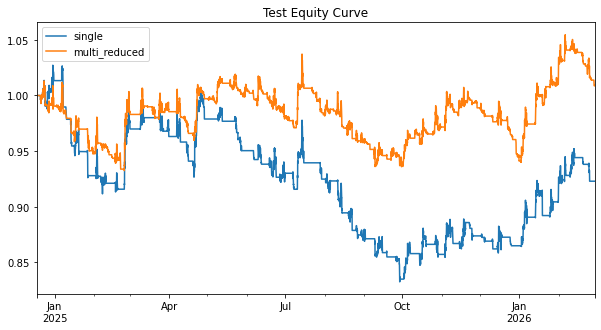

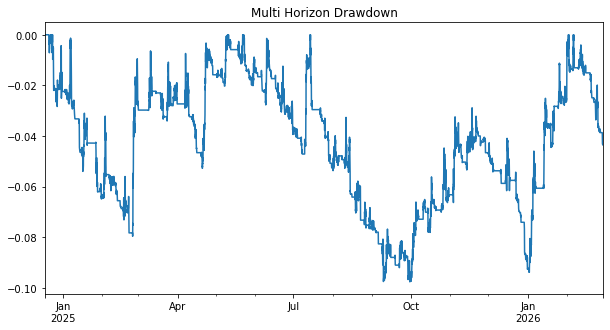

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bt_single_test["equity"].plot(label="single")
bt_multi_test["equity"].plot(label="multi_reduced")

plt.legend()
plt.title("Test Equity Curve")
plt.show()

plt.figure(figsize=(10,5))

bt_multi_test["drawdown"].plot()

plt.title("Multi Horizon Drawdown")
plt.show()

为什么 multi-horizon momentum 更稳定？

第一层： 不同时间尺度的趋势结构

市场趋势不是单一时间尺度的，如果只用一个horizon，一旦尺度失效，策略就会失效。

第二层： alpha diversification

多期信号的本质上多个alpha sleeve

例如短期中期长期趋势，他们之间的相关系数0.-0.8

因此组合后Pnl variance会降低，也就是sharpe提高，最大回撤降低

第三层：不同regime的robustness

当市场regime变化是，部分horizon会失效，多期更robust
